In [ ]:
run_ssc_eval.sh

In [40]:
import pathlib

# Load the individual models results
# res_root = pathlib.Path("/work/results/t5-base/ssc")
res_root = pathlib.Path("/work/results/ut5-base/Spider4SSC/clean/ep19")
res_root_single = res_root.joinpath("single")

langs = ["sparql", "sql", "cypher"]
schemas = ["no_schema", "schema/norange", "schema/compact"]
res_file_name = "all_results.json"


colors = {
    "cypher": "#4477AA",  # blue
    "sparql": "#228833",  # green
    "sql": "#CCBB44",     # yellow
}

darker_colors = {
    "cypher": "#225588",
    "sparql": "#116622",
    "sql": "#AA9900",
}


In [41]:
import json
import pandas as pd

rq4_res_root = res_root / "RQ4"
rq4_res_root.mkdir(parents=True, exist_ok=True)

df_individual = pd.DataFrame(index=langs, columns=schemas)
for lang in langs:
    for schema in schemas:
        pth = res_root_single.joinpath(lang, schema, res_file_name)
        all_results = json.load(pth.open())
        df_individual.loc[lang, schema] = all_results['eval_exec']

df_individual = df_individual*100 # convert to percentage

print("Individual models results:")
print(df_individual)
df_individual.to_csv(rq4_res_root / "individual_models_results.csv")

Individual models results:
       no_schema schema/norange schema/compact
sparql  4.111842      17.763158      22.368421
sql        9.375      36.842105      37.006579
cypher  6.578947      38.815789      35.197368


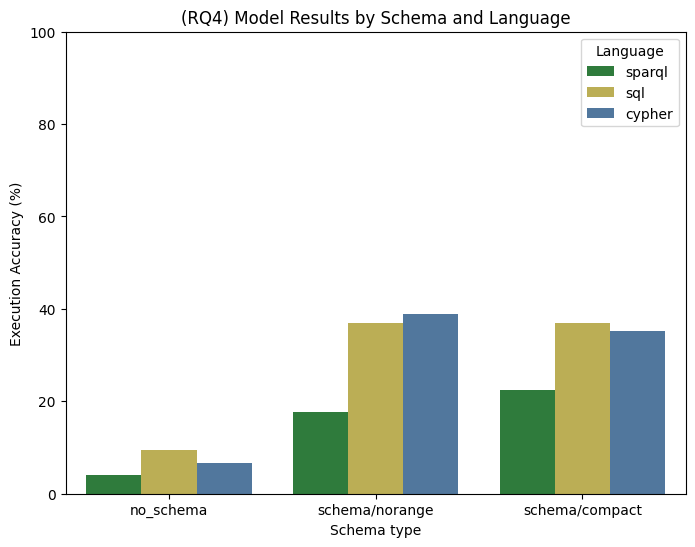

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_individual.reset_index().melt(
    id_vars='index', var_name='Schema type', value_name='Accuracy'
)
df_plot.rename(columns={'index': 'Language'}, inplace=True)

plt.figure(figsize=(8,6))
sns.barplot(
    data=df_plot,
    x="Schema type", y="Accuracy", hue="Language",
    palette=colors
)

plt.ylabel("Execution Accuracy (%)")
plt.title("(RQ4) Model Results by Schema and Language")
plt.ylim(0, 100)
plt.legend(title="Language")
plot_res = rq4_res_root / "T5_schema-vs-language"
plot_res.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_res / "RQ4_T5_schema-vs-language.png", dpi=300)
plt.savefig(plot_res / "RQ4_T5_schema-vs-language.svg")
plt.savefig(plot_res / "RQ4_T5_schema-vs-language.pdf")
plt.show()

In [ ]:
run_ssc_eval_joint.sh

In [43]:
import json
import pandas as pd
import pathlib

# Load the joint model results
# res_root_joint = pathlib.Path("/work/results/t5-base/ssc/joint/")
res_root_joint = res_root.joinpath("joint/eval")
langs = ["sparql", "sql", "cypher"]
schemas = ["no_schema", "schema/norange", "schema/compact"]
res_file_name_joint = "eval_results.json"

rq5_res_root = res_root / "RQ5"
rq5_res_root.mkdir(parents=True, exist_ok=True)

df_joint = pd.DataFrame(index=langs, columns=schemas)
for lang in langs:
    for schema in schemas:
        pth = res_root_joint.joinpath(lang, schema, res_file_name_joint)
        all_results = json.load(pth.open())
        df_joint.loc[lang, schema] = all_results['eval_exec']

df_joint = df_joint*100 # convert to percentage

print("Joint model results:")
print(df_joint)

Joint model results:
        no_schema schema/norange schema/compact
sparql   4.111842         15.625      23.355263
sql     10.855263      40.296053      39.473684
cypher   6.578947      35.690789      32.072368


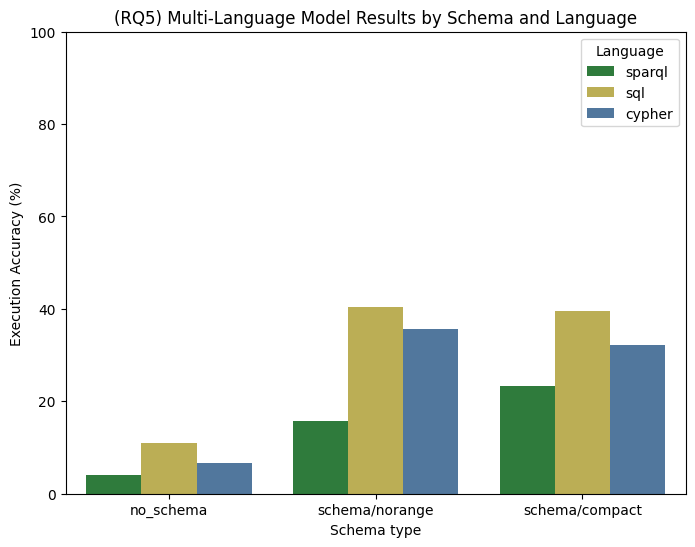

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_joint.reset_index().melt(
    id_vars='index', var_name='Schema type', value_name='Accuracy'
)
df_plot.rename(columns={'index': 'Language'}, inplace=True)

plt.figure(figsize=(8,6))
sns.barplot(
    data=df_plot,
    x="Schema type", y="Accuracy", hue="Language",
    palette=colors
)

plt.ylabel("Execution Accuracy (%)")
plt.title("(RQ5) Multi-Language Model Results by Schema and Language")
plt.ylim(0, 100)
plt.legend(title="Language")
plot_res = rq5_res_root / "T5_schema-vs-language"
plot_res.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_res / "RQ5_T5_schema-vs-language.png", dpi=300)
plt.savefig(plot_res / "RQ5_T5_schema-vs-language.svg")
plt.savefig(plot_res / "RQ5_T5_schema-vs-language.pdf")
plt.show()

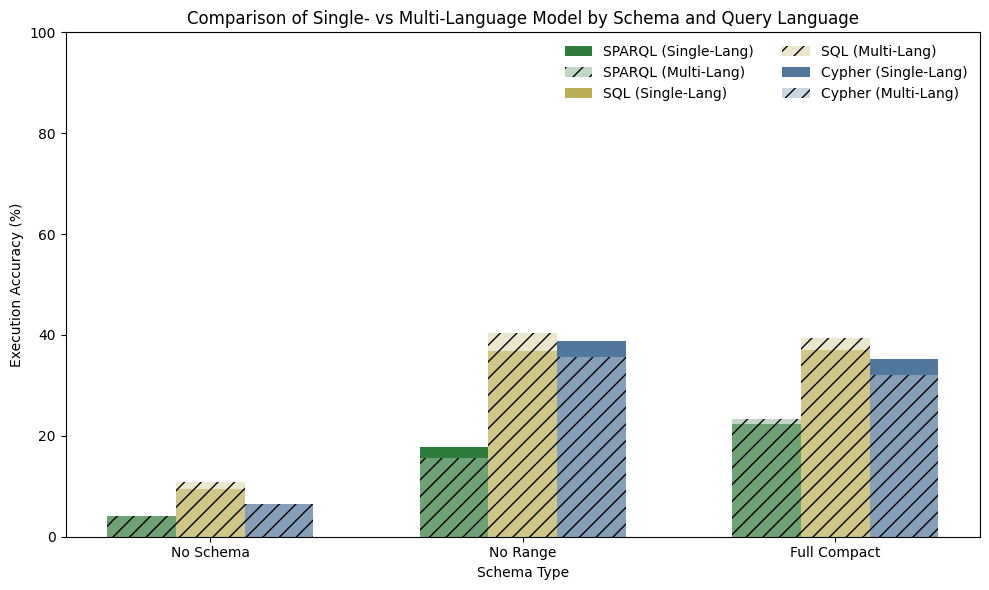

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# --- Prepare data ---
schemas = ['No Schema', 'No Range', 'Full Compact']
languages = ['SPARQL', 'SQL', 'Cypher']

# from df_individual and df_joint (in %)
EX_single = np.array([
    df_individual.loc['sparql'].values,
    df_individual.loc['sql'].values,
    df_individual.loc['cypher'].values
], dtype=float)

EX_joint = np.array([
    df_joint.loc['sparql'].values,
    df_joint.loc['sql'].values,
    df_joint.loc['cypher'].values
], dtype=float)

# --- Colors ---
colors = {
    'SPARQL': '#2F7B3B',
    'SQL':    '#BCAE55',
    'Cypher': '#51779C',
}

def lighten(color, amount=0.5):
    c = np.array(to_rgba(color))
    white = np.array([1, 1, 1, 1])
    return tuple(c + (white - c) * amount)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.22
index = np.arange(len(schemas))

for i, lang in enumerate(languages):
    color_single = colors[lang]
    ax.bar(index + i*bar_width, EX_single[i], bar_width,
           label=f'{lang} (Single-Lang)', color=color_single)
    color_joint = lighten(colors[lang], 0.5)
    ax.bar(index + i*bar_width, EX_joint[i], bar_width,
           label=f'{lang} (Multi-Lang)', color=color_joint, hatch='//', alpha=0.6)

ax.set_xlabel('Schema Type')
ax.set_ylabel('Execution Accuracy (%)')
ax.set_title('Comparison of Single- vs Multi-Language Model by Schema and Query Language')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(schemas)
ax.set_ylim(0, 100)

# Unique legend
handles, labels = ax.get_legend_handles_labels()
seen, unique_handles, unique_labels = set(), [], []
for h, l in zip(handles, labels):
    if l not in seen:
        unique_handles.append(h)
        unique_labels.append(l)
        seen.add(l)
ax.legend(unique_handles, unique_labels, ncol=2, frameon=False)

plt.tight_layout()

plot_path = rq5_res_root / "T5_single-vs-joint-schema"
plot_path.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_path / "RQ5_T5_single-vs-joint-schema.png", dpi=300)
plt.savefig(plot_path / "RQ5_T5_single-vs-joint-schema.pdf", bbox_inches='tight')
plt.savefig(plot_path / "RQ5_T5_single-vs-joint-schema.svg", bbox_inches='tight')
plt.show()

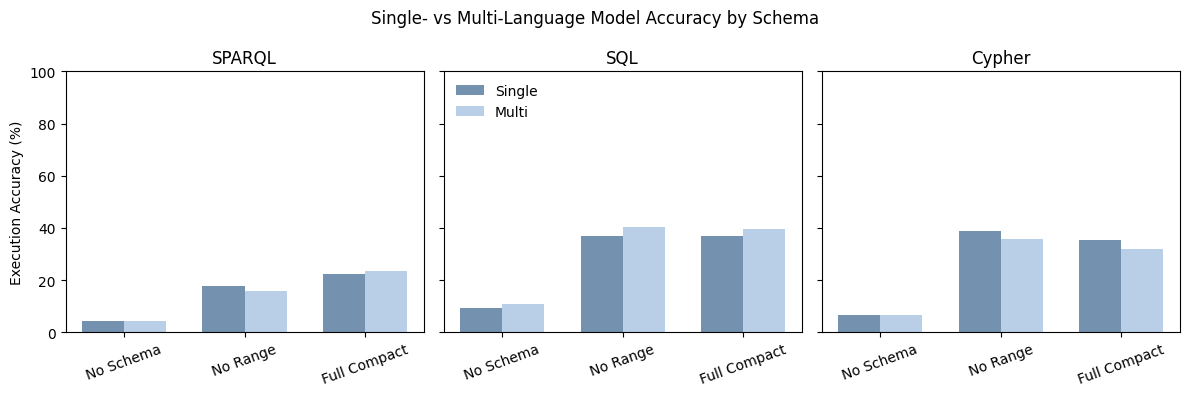

In [46]:
import matplotlib.pyplot as plt
import numpy as np

schemas = ['No Schema', 'No Range', 'Full Compact']
languages = ['SPARQL', 'SQL', 'Cypher']
bar_width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for i, lang in enumerate(languages):
    ax = axes[i]
    single = df_individual.loc[lang.lower()].values.astype(float)
    joint = df_joint.loc[lang.lower()].values.astype(float)
    x = np.arange(len(schemas))

    ax.bar(x - bar_width/2, single, bar_width, label='Single', color='#51779C', alpha=0.8)
    ax.bar(x + bar_width/2, joint, bar_width, label='Multi', color='#A8C4E3', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(schemas, rotation=20)
    ax.set_title(lang)
    ax.set_ylim(0, 100)
    if i == 0:
        ax.set_ylabel('Execution Accuracy (%)')
    if i == 1:
        ax.legend(frameon=False, loc='upper left')

plt.suptitle('Single- vs Multi-Language Model Accuracy by Schema')
plt.tight_layout()
plt.show()


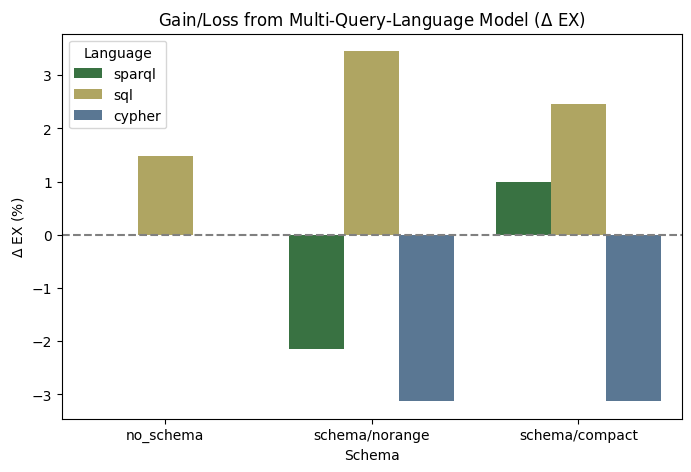

In [47]:
import pandas as pd

df_diff = (df_joint - df_individual)
df_diff_plot = df_diff.reset_index().melt(id_vars='index', var_name='Schema', value_name=r'$\Delta$ EX')
df_diff_plot.rename(columns={'index':'Language'}, inplace=True)

colors_lowercase = {k.lower(): v for k, v in colors.items()}

plt.figure(figsize=(8,5))
sns.barplot(data=df_diff_plot, x='Schema', y=r'$\Delta$ EX', hue='Language', palette=colors_lowercase)
plt.axhline(0, color='gray', linestyle='--')
plt.title(r'Gain/Loss from Multi-Query-Language Model ($\Delta$ EX)')
plt.ylabel(r'$\Delta$ EX (%)')
plot_path = rq5_res_root / "delta"
plot_path.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_path / "RQ5_single-vs-joint-delta.png", dpi=300)
plt.savefig(plot_path / "RQ5_single-vs-joint-delta.pdf", bbox_inches='tight')
plt.savefig(plot_path / "RQ5_single-vs-joint-delta.svg", bbox_inches='tight')
plt.show()


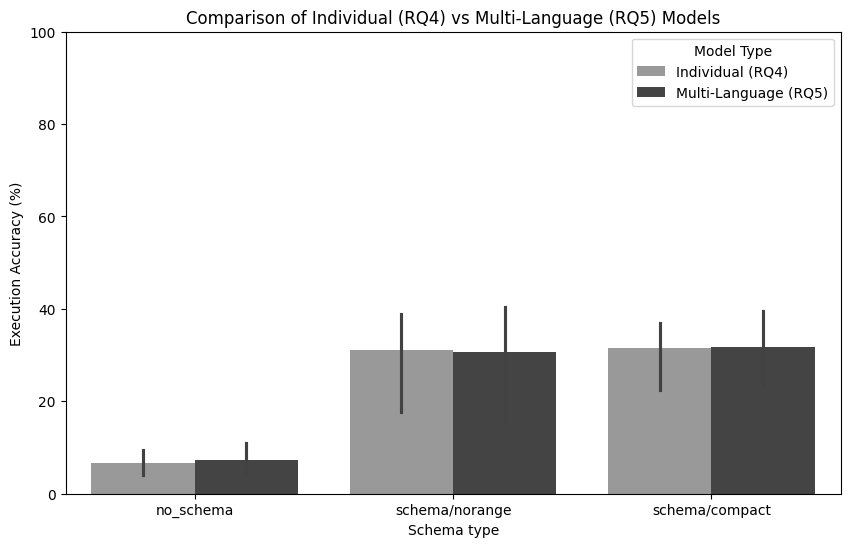

In [ ]:
# Combine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure df_individual (RQ4) and df_joint (RQ5) are ready
df_rq4 = df_individual.copy()
df_rq4['RQ'] = 'Individual (RQ4)'

df_rq5 = df_joint.copy()
df_rq5['RQ'] = 'Multi-Language (RQ5)'

# Melt to long format
df_rq4_plot = df_rq4.reset_index().melt(
    id_vars=['index','RQ'], var_name='Schema type', value_name='Accuracy'
).rename(columns={'index':'Language'})

df_rq5_plot = df_rq5.reset_index().melt(
    id_vars=['index','RQ'], var_name='Schema type', value_name='Accuracy'
).rename(columns={'index':'Language'})

df_combined = pd.concat([df_rq4_plot, df_rq5_plot], ignore_index=True)

# Plot grouped barplot
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_combined,
    x="Schema type", y="Accuracy",
    hue="RQ",  # differentiate RQ4 vs RQ5
    palette={"Individual (RQ4)":"#999999", "Multi-Language (RQ5)":"#444444"},  # greys for RQ dimension
)

plt.ylabel("Execution Accuracy (%)")
plt.title("Comparison of Individual (RQ4) vs Multi-Language (RQ5) Models")
plt.ylim(0, 100)
plt.legend(title="Model Type")

plot_res = rq5_res_root / "RQ4_vs_RQ5"
plot_res.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_res / "RQ4_vs_RQ5_comparison.png", dpi=300)
plt.savefig(plot_res / "RQ4_vs_RQ5_comparison.svg")
plt.savefig(plot_res / "RQ4_vs_RQ5_comparison.pdf")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

def plot_rq4_vs_rq5_no_gaps(df_individual, df_joint, langs, schemas, colors, darker_colors, out_dir):
    """
    Create a bar plot with no inter-group gaps for RQ4 vs RQ5 across Schema × Language.
    Groups bars by schema type first (no_schema, schema/norange, schema/compact).
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Flatten data schema-first
    xs_labels = []
    vals_rq4 = []
    vals_rq5 = []
    langs_for_tick = []
    schemas_for_tick = []

    for schema in schemas:         # outer loop is schema first
        for lang in langs:         # then language inside
            xs_labels.append(f"{schema} | {lang}")
            vals_rq4.append(float(df_individual.loc[lang, schema]))
            vals_rq5.append(float(df_joint.loc[lang, schema]))
            langs_for_tick.append(lang)
            schemas_for_tick.append(schema)

    n = len(xs_labels)

    # Geometry
    group_width = 1.0
    bar_width = group_width / 2.0
    x0 = np.arange(n)
    x_rq4 = x0
    x_rq5 = x0 + bar_width

    # Colors
    color_rq4 = [colors[l] for l in langs_for_tick]
    color_rq5 = [darker_colors[l] for l in langs_for_tick]

    fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

    ax.bar(x_rq4, vals_rq4, width=bar_width, color=color_rq4, edgecolor="none")
    ax.bar(x_rq5, vals_rq5, width=bar_width, color=color_rq5, edgecolor="none")

    # Ticks at center of group
    ax.set_xticks(x0 + group_width/2)
    ax.set_xticklabels(xs_labels, rotation=30, ha="right")

    ax.set_ylabel("Execution Accuracy (%)")
    ax.set_title("RQ4 vs RQ5 Model Comparison (Schema × Language)")
    ax.set_ylim(0, 100)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)
    ax.set_axisbelow(True)

    # Legend
    legend_handles = [
        Patch(facecolor='#999999', edgecolor="none", label="Individual (RQ4)"),
        Patch(facecolor='#444444', edgecolor="none", label="Multi-Language (RQ5)"),
    ]
    ax.legend(handles=legend_handles, title="Model Type", frameon=False)

    # Optional vertical separators between schema blocks
    idx = 0
    for schema in schemas:
        idx += len(langs)
        if idx < n:
            ax.axvline(idx-0.25, color="white", linewidth=5)

    fig.tight_layout()
    fig.savefig(out_dir / "RQ4_vs_RQ5_schema_first.png", dpi=300)
    fig.savefig(out_dir / "RQ4_vs_RQ5_schema_first.svg")
    fig.savefig(out_dir / "RQ4_vs_RQ5_schema_first.pdf")
    plt.show()


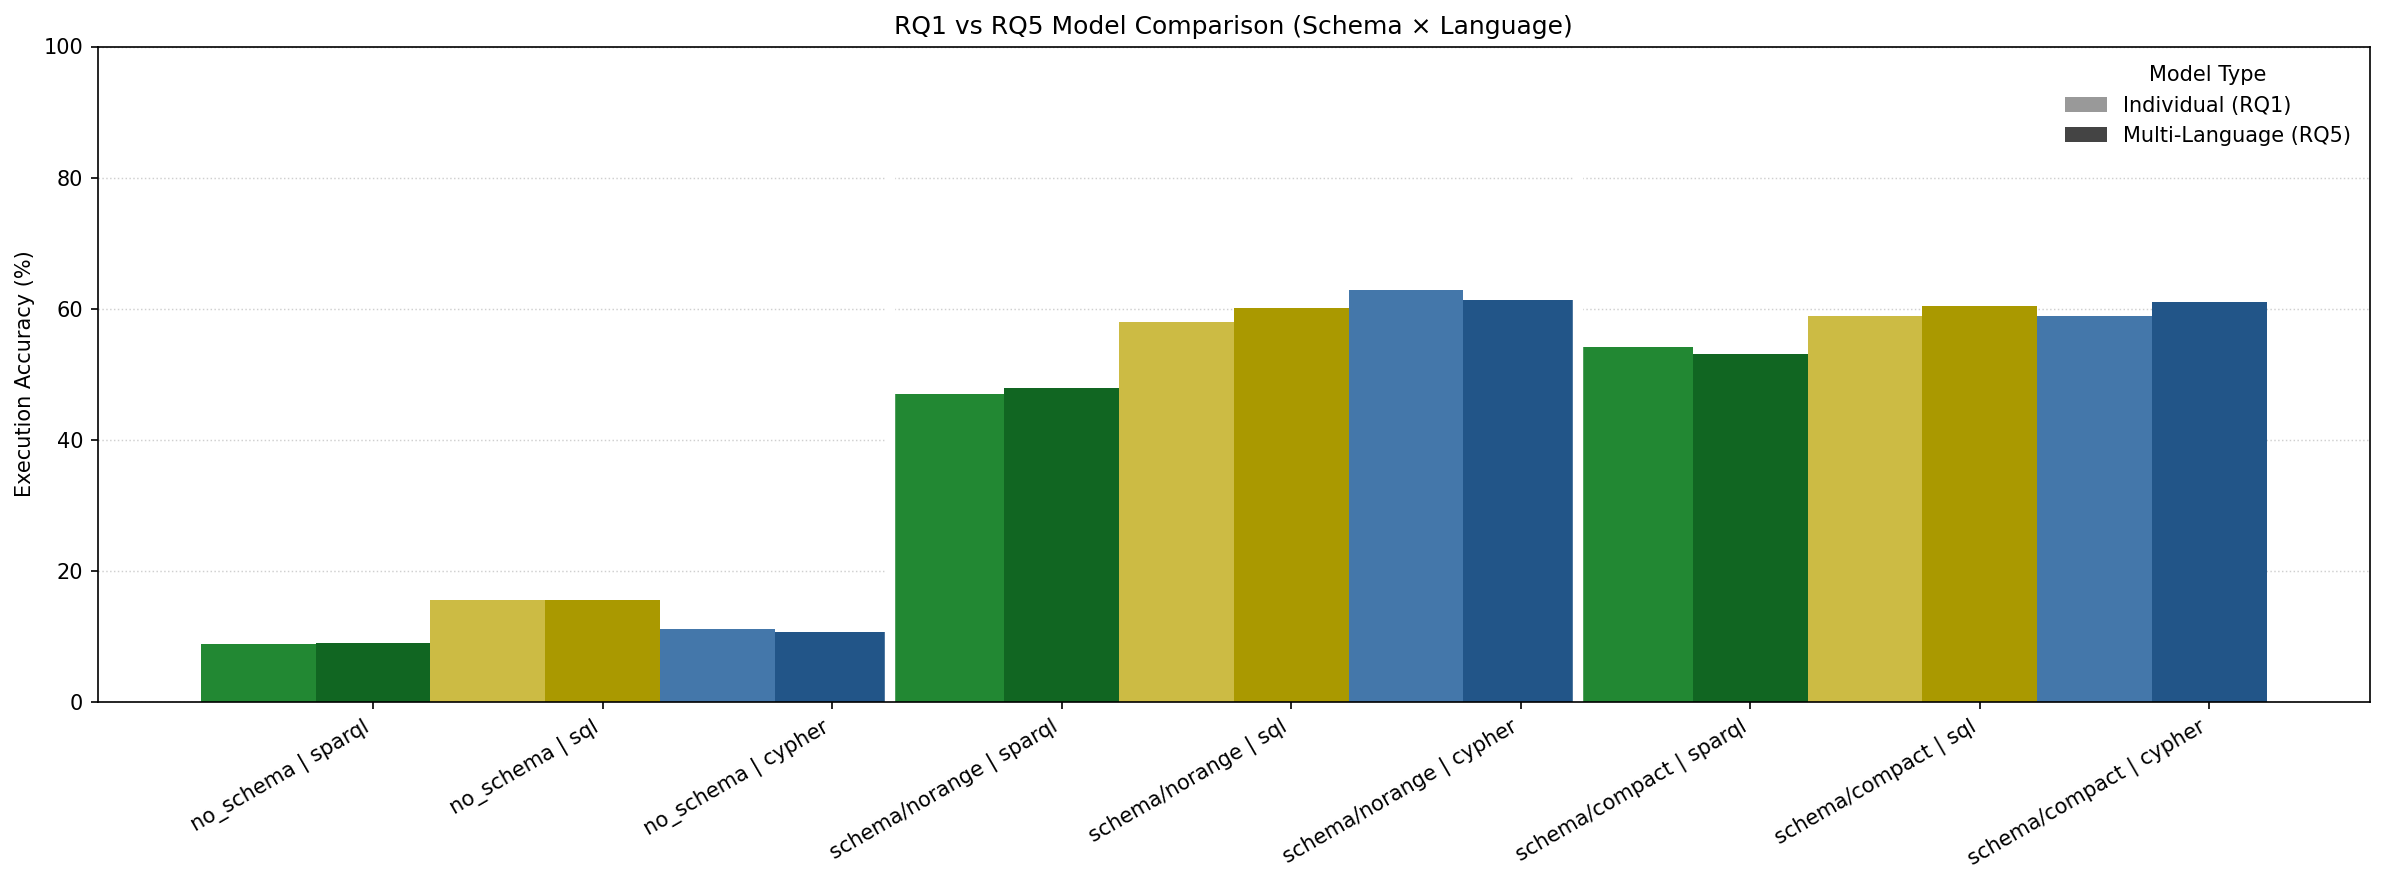

In [ ]:
plot_rq4_vs_rq5_no_gaps(df_individual, df_joint, langs, schemas, colors, darker_colors, plot_res)

In [ ]:
import pandas as pd

def make_comparison_dataframe(df_individual, df_joint, langs, schemas):
    records = []
    for lang in langs:
        for schema in schemas:
            records.append({
                "Language": lang,
                "Schema type": schema,
                "RQ": "Individual (RQ4)",
                "Accuracy": float(df_individual.loc[lang, schema])
            })
            records.append({
                "Language": lang,
                "Schema type": schema,
                "RQ": "Multi-Language (RQ5)",
                "Accuracy": float(df_joint.loc[lang, schema])
            })
    return pd.DataFrame(records)

# --- build long format ---
df_comparison = make_comparison_dataframe(df_individual, df_joint, langs, schemas)

# --- pivot into wide table ---
df_pivot = df_comparison.pivot_table(
    index=["Schema type", "Language"],
    columns="RQ", values="Accuracy"
).reset_index()

# --- pretty schema names ---
schema_labels = {
    "no_schema": "No Schema",
    "schema/norange": "No Range",
    "schema/compact": "Full Compact",
}
df_pivot["Schema type"] = df_pivot["Schema type"].map(schema_labels)

# --- order schema + language ---
schema_order = ["No Schema", "No Range", "Full Compact"]
lang_order = ["sparql", "sql", "cypher"]

df_pivot["Schema type"] = pd.Categorical(df_pivot["Schema type"], categories=schema_order, ordered=True)
df_pivot["Language"] = pd.Categorical(df_pivot["Language"], categories=lang_order, ordered=True)

df_pivot = df_pivot.sort_values(["Schema type", "Language"]).reset_index(drop=True)

# --- round for readability (optional) ---
df_pivot = df_pivot.round(2)

print(df_pivot)
df_pivot.to_csv(plot_res / "RQ4_vs_RQ5_comparison_pivot.csv", index=False)

RQ   Schema type Language  Individual (RQ1)  Multi-Language (RQ5)
0      No Schema   sparql              8.72                  8.88
1      No Schema      sql             15.46                 15.46
2      No Schema   cypher             11.02                 10.69
3       No Range   sparql             46.88                 47.86
4       No Range      sql             57.89                 60.03
5       No Range   cypher             62.83                 61.35
6   Full Compact   sparql             54.11                 53.12
7   Full Compact      sql             58.88                 60.36
8   Full Compact   cypher             58.88                 61.02


In [21]:
# Save both dataframes into a single Excel file with separate sheets
output_file = "results.xlsx"
with pd.ExcelWriter(output_file) as writer:
    df_individual.to_excel(writer, sheet_name="individual models")
    df_joint.to_excel(writer, sheet_name="joint model")

print(f"DataFrames saved to {output_file}")


DataFrames saved to results.xlsx


# VLLM eval

In [6]:
import json
import pandas as pd
import pathlib

# Load the joint model results
res_root_joint = pathlib.Path("~/git/uT5-ssc/results/qwen-14b/ssc/")
res_file_name_joint = "evaluation_results.json"

df_joint = pd.DataFrame(index=langs, columns=schemas)
for lang in langs:
    for schema in schemas:
        pth = res_root_joint.joinpath(lang, schema, res_file_name_joint)
        all_results = json.load(pth.open())
        df_joint.loc[lang, schema] = all_results["scores"]["turn 1"]["exec"]

print("Joint model results:")
print(df_joint)

Joint model results:
       no_schema schema/norange schema/compact
sql        0.125       0.723684       0.751645
sparql       0.0       0.126645       0.143092
cypher  0.018092        0.03125       0.203947


In [14]:
import json
import pandas as pd
import pathlib

langs = ["sql", "sparql", "cypher"]
schemas = ["no_schema", "schema/norange", "schema/compact"]
res_file_name = "evaluation_results.json"
models = [
  "meta-llama/Llama-2-7b-chat-hf",
  "meta-llama/Llama-2-13b-chat-hf",
  "meta-llama/Llama-3.1-8B-Instruct",
  "Qwen/Qwen2.5-7B-Instruct-1M",
  "Qwen/Qwen2.5-14B-Instruct-1M",
  "meta-llama/CodeLlama-7b-hf",
  "meta-llama/CodeLlama-13b-Instruct-hf"
]

# Create an Excel writer (adjust the file name as needed)
excel_file = "model_evaluation_results.xlsx"
with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    for model in models:
        # Prepare the path for the joint results
        res_root_joint = pathlib.Path(f"~/git/uT5-ssc/results/{model}/ssc/")
        df_joint = pd.DataFrame(index=langs, columns=schemas)
        valid_results = False  # flag to check if any eval result is found

        # Iterate over languages and schemas to try and load results
        for lang in langs:
            for schema in schemas:
                pth = res_root_joint.joinpath(lang, schema, res_file_name)
                if pth.is_file():
                    try:
                        all_results = json.load(pth.open())
                        # Assuming the structure contains the keys as in your snippet
                        df_joint.loc[lang, schema] = all_results["scores"]["turn 1"]["exec"]
                        valid_results = True
                    except Exception as e:
                        # In case JSON structure is unexpected or any error occurs, leave the cell as NaN
                        print(f"Error loading {pth}: {e}")
                        df_joint.loc[lang, schema] = None
                else:
                    # File does not exist; leave the cell as NaN
                    df_joint.loc[lang, schema] = None

        # Replace "/" with "__" and truncate to 31 characters for Excel sheet name
        safe_sheet_name = model.replace("/", "__")[:31]

        # Write the DataFrame to a sheet named after the model
        if valid_results:
            df_joint.to_excel(writer, sheet_name=safe_sheet_name)
        else:
            # Create an empty DataFrame and write it so the sheet exists but is empty.
            pd.DataFrame().to_excel(writer, sheet_name=safe_sheet_name)

        print(f"Processed model: {model} -> Sheet name: {safe_sheet_name}")

print("Saved all model results to", excel_file)

Processed model: meta-llama/Llama-2-7b-chat-hf -> Sheet name: meta-llama__Llama-2-7b-chat-hf
Processed model: meta-llama/Llama-2-13b-chat-hf -> Sheet name: meta-llama__Llama-2-13b-chat-hf
Processed model: meta-llama/Llama-3.1-8B-Instruct -> Sheet name: meta-llama__Llama-3.1-8B-Instru
Processed model: Qwen/Qwen2.5-7B-Instruct-1M -> Sheet name: Qwen__Qwen2.5-7B-Instruct-1M
Processed model: Qwen/Qwen2.5-14B-Instruct-1M -> Sheet name: Qwen__Qwen2.5-14B-Instruct-1M
Processed model: meta-llama/CodeLlama-7b-hf -> Sheet name: meta-llama__CodeLlama-7b-hf
Processed model: meta-llama/CodeLlama-13b-Instruct-hf -> Sheet name: meta-llama__CodeLlama-13b-Instr
Saved all model results to model_evaluation_results.xlsx


# for multi-run averages

In [1]:
import json
import pandas as pd
import pathlib
import numpy as np

langs = ["sql", "sparql", "cypher"]
schemas = ["no_schema", "schema/norange", "schema/compact"]
res_file_pattern = "**/evaluation_results.json"
models = [
"meta-llama/Llama-3.1-8B-Instruct",
"deepseek-ai/DeepSeek-R1-Distill-Qwen-14B",
"Qwen/Qwen2.5-7B-Instruct-1M",
"Qwen/Qwen2.5-14B-Instruct-1M",
"meta-llama/CodeLlama-7b-Instruct-hf",
"meta-llama/CodeLlama-13b-Instruct-hf",
"meta-llama/Llama-2-7b-chat-hf",
"meta-llama/Llama-2-13b-chat-hf",
]

excel_file = "model_evaluation_results.xlsx"
with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    for model in models:
        res_root_joint = pathlib.Path(f"~/git/uT5-ssc/results/{model}/ssc/")
        df_joint = pd.DataFrame(index=langs, columns=schemas)
        valid_results = False

        for lang in langs:
            for schema in schemas:
                pth_dir = res_root_joint.joinpath(lang, schema)
                result_files = list(pth_dir.glob(res_file_pattern))
                if result_files:
                    scores = []
                    for f in result_files:
                        try:
                            all_results = json.load(f.open())
                            # Assuming "turn 1" exec score is stored at:
                            score = all_results["scores"]["turn 1"]["exec"]
                            scores.append(score)
                        except Exception as e:
                            print(f"Error loading {f}: {e}")
                    if scores:
                        avg_score = np.mean(scores)
                        df_joint.loc[lang, schema] = avg_score
                        valid_results = True
                    else:
                        df_joint.loc[lang, schema] = None
                else:
                    df_joint.loc[lang, schema] = None

        safe_sheet_name = model.replace("/", "__")[:31]
        if valid_results:
            df_joint.to_excel(writer, sheet_name=safe_sheet_name)
        else:
            pd.DataFrame().to_excel(writer, sheet_name=safe_sheet_name)
        print(f"Processed model: {model} -> Sheet name: {safe_sheet_name}")

print("Saved all model results to", excel_file)

Processed model: meta-llama/Llama-3.1-8B-Instruct -> Sheet name: meta-llama__Llama-3.1-8B-Instru
Processed model: deepseek-ai/DeepSeek-R1-Distill-Qwen-14B -> Sheet name: deepseek-ai__DeepSeek-R1-Distil
Processed model: Qwen/Qwen2.5-7B-Instruct-1M -> Sheet name: Qwen__Qwen2.5-7B-Instruct-1M
Processed model: Qwen/Qwen2.5-14B-Instruct-1M -> Sheet name: Qwen__Qwen2.5-14B-Instruct-1M
Processed model: meta-llama/CodeLlama-7b-Instruct-hf -> Sheet name: meta-llama__CodeLlama-7b-Instru
Processed model: meta-llama/CodeLlama-13b-Instruct-hf -> Sheet name: meta-llama__CodeLlama-13b-Instr
Processed model: meta-llama/Llama-2-7b-chat-hf -> Sheet name: meta-llama__Llama-2-7b-chat-hf
Processed model: meta-llama/Llama-2-13b-chat-hf -> Sheet name: meta-llama__Llama-2-13b-chat-hf
Saved all model results to model_evaluation_results.xlsx
